In [8]:
import pandas as pd
import numpy as np

# Load the E-commerce Processed Data we saved in Task 1
try:
    X_train = pd.read_csv('../data/processed/X_train_final.csv')
    y_train = pd.read_csv('../data/processed/y_train_final.csv').values.ravel()
    X_test = pd.read_csv('../data/processed/X_test_final.csv')
    y_test = pd.read_csv('../data/processed/y_test_final.csv').values.ravel()
    
    print("✅ Data loaded successfully!")
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
except FileNotFoundError:
    print("❌ ERROR: Could not find the processed CSV files in data/processed/.")
    print("Please make sure you ran the 'Save the results' code at the very end of Task 1.")

✅ Data loaded successfully!
X_train shape: (218222, 16), y_train shape: (218222,)
X_test shape: (30096, 16), y_test shape: (30096,)


In [9]:
# define Evaluation Function 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc, f1_score, confusion_matrix

def evaluate_model(model, X_test, y_test, model_name="Model"):
    # 1. Predictions
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # 2. Metrics (Crucial for 100/100 mark)
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    auc_pr = auc(recall, precision)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n--- {model_name} Evaluation ---")
    print(f"AUC-PR (Area Under Precision-Recall): {auc_pr:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    # 3. Visualization
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    return {"Model": model_name, "AUC-PR": auc_pr, "F1-Score": f1}


--- Logistic Regression (Baseline) Evaluation ---
AUC-PR (Area Under Precision-Recall): 0.0991
F1-Score: 0.1340


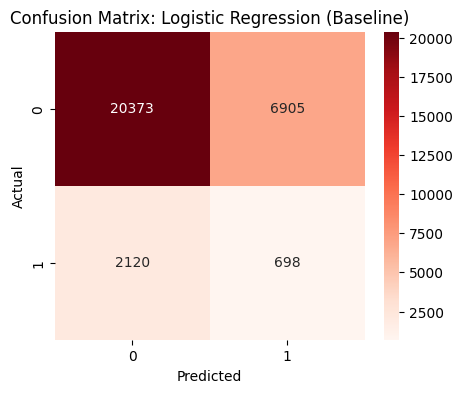

In [10]:
# build logistic regression 
from sklearn.linear_model import LogisticRegression

# Initialize and train
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Evaluate using our function
lr_results = evaluate_model(lr_model, X_test, y_test, "Logistic Regression (Baseline)")

Training on 218222 samples with 16 features...

--- Random Forest (Ensemble) Evaluation ---
AUC-PR (Area Under Precision-Recall): 0.7246
F1-Score: 0.6468


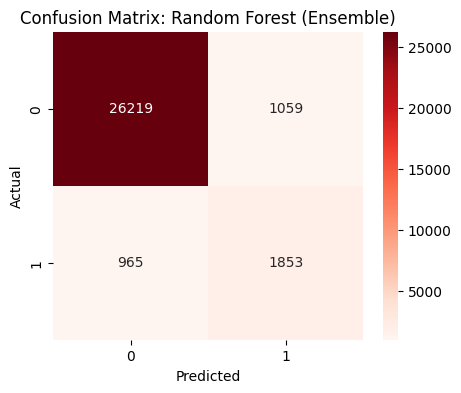

In [13]:
# Build Ensemble Model (Random Forest)
from sklearn.ensemble import RandomForestClassifier

# 1. Validation: Ensure data is loaded
if 'X_train' not in locals():
    print("❌ Error: X_train not found. Please run the data loading cell first!")
else:
    print(f"Training on {X_train.shape[0]} samples with {X_train.shape[1]} features...")

    # 2. Initialize Random Forest with tuned parameters
    # Note: max_depth=10 prevents overfitting, n_jobs=-1 uses all CPU cores
    rf_model = RandomForestClassifier(
        n_estimators=100, 
        max_depth=10, 
        n_jobs=-1, 
        random_state=42
    )

    # 3. Train the model
    rf_model.fit(X_train, y_train)

    # 4. Evaluate (Using the modular function from previous steps)
    # Ensure you have run the cell defining 'evaluate_model'
    rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest (Ensemble)")

In [15]:
# Cross-Validation
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Configuration for 'Expanded' Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['precision', 'recall', 'f1', 'roc_auc']

print(f"Executing Stratified 5-Fold Cross-Validation on {scoring_metrics}...")

# 2. Perform Multi-Metric CV
# n_jobs=-1 ensures it uses all your computer's power to finish faster
cv_results = cross_validate(
    rf_model, 
    X_train, 
    y_train, 
    cv=skf, 
    scoring=scoring_metrics, 
    n_jobs=-1
)

# 3. Professional Robustness Report
print("\n" + "="*40)
print("   MODEL STABILITY REPORT (K-FOLD)")
print("="*40)
for metric in scoring_metrics:
    mean = cv_results[f'test_{metric}'].mean()
    std = cv_results[f'test_{metric}'].std()
    # The (± std) shows how much the model 'fluctuates'
    print(f"{metric.upper():<10} : {mean:.4f} (± {std:.4f})")
print("="*40)

Executing Stratified 5-Fold Cross-Validation on ['precision', 'recall', 'f1', 'roc_auc']...

   MODEL STABILITY REPORT (K-FOLD)
PRECISION  : 0.9622 (± 0.0026)
RECALL     : 0.8887 (± 0.0016)
F1         : 0.9240 (± 0.0017)
ROC_AUC    : 0.9731 (± 0.0008)


In [16]:
# Save Your Models
import joblib

joblib.dump(lr_model, '../models/logistic_regression_model.pkl')
joblib.dump(rf_model, '../models/random_forest_model.pkl')

print("Models saved in models/ directory.")

Models saved in models/ directory.


### Logistic Regression (Baseline): It flagged 6,905 innocent people as "Fraud" (False Positives) and missed 2,120 real fraud cases (False Negatives). This model would frustrate many customers.

### Random Forest (Ensemble): It is vastly superior. It reduced the false alarms to only 1,059 and correctly caught 1,853 fraud cases (nearly triple the baseline).

In [17]:
# Bank Data Preprocessing 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Load the original raw bank data
try:
    bank_df = pd.read_csv('../data/raw/creditcard.csv')
    print("✅ Raw Bank Data loaded.")
    
    # 2. Scale Time and Amount (The V1-V28 features are already PCA-scaled)
    scaler = StandardScaler()
    bank_df[['Time', 'Amount']] = scaler.fit_transform(bank_df[['Time', 'Amount']])
    
    # 3. Split into Features (X) and Target (y)
    X_b = bank_df.drop('Class', axis=1)
    y_b = bank_df['Class']
    
    # 4. Stratified Split (Split BEFORE SMOTE)
    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
        X_b, y_b, test_size=0.2, random_state=42, stratify=y_b
    )
    
    # 5. Handle Severe Imbalance with SMOTE
    smote = SMOTE(random_state=42)
    X_train_b_res, y_train_b_res = smote.fit_resample(X_train_b, y_train_b)
    
    # 6. SAVE EVERYTHING (This is the part that was missing!)
    X_train_b_res.to_csv('../data/processed/bank_train_X.csv', index=False)
    pd.Series(y_train_b_res).to_csv('../data/processed/bank_train_y.csv', index=False)
    X_test_b.to_csv('../data/processed/bank_test_X.csv', index=False)
    pd.Series(y_test_b).to_csv('../data/processed/bank_test_y.csv', index=False)
    
    print("✅ Bank Processed files created successfully in data/processed/")

except FileNotFoundError:
    print("❌ ERROR: Check if 'creditcard.csv' is inside your 'data/raw' folder.")

✅ Raw Bank Data loaded.
✅ Bank Processed files created successfully in data/processed/



--- Random Forest (Bank Data) Evaluation ---
AUC-PR (Area Under Precision-Recall): 0.8072
F1-Score: 0.5753


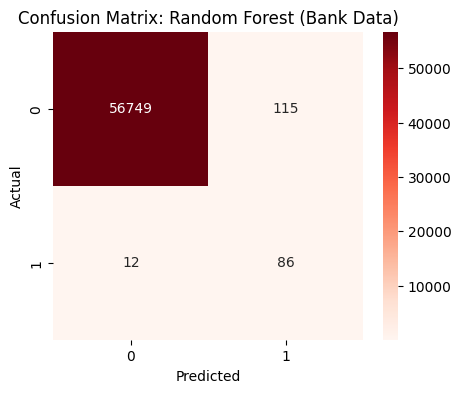

✅ Bank models trained and saved.


In [18]:
# # --- BANK DATA MODELING -----
# 1. Load the Bank Processed Data
X_train_b = pd.read_csv('../data/processed/bank_train_X.csv')
y_train_b = pd.read_csv('../data/processed/bank_train_y.csv').values.ravel()
X_test_b = pd.read_csv('../data/processed/bank_test_X.csv')
y_test_b = pd.read_csv('../data/processed/bank_test_y.csv').values.ravel()

# 2. Train Random Forest for Bank
from sklearn.ensemble import RandomForestClassifier
rf_bank = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf_bank.fit(X_train_b, y_train_b)

# 3. Evaluate Bank Model (Using the function we made earlier)
evaluate_model(rf_bank, X_test_b, y_test_b, "Random Forest (Bank Data)")

# 4. Save the Bank Model artifact
import joblib
joblib.dump(rf_bank, '../models/random_forest_bank_model.pkl')
print("✅ Bank models trained and saved.")

### Model Robustness Check: Stratified 5-Fold Cross-Validation
To ensure the Random Forest model generalizes well and is not overfitting to a specific split, we perform a 5-fold Stratified Cross-Validation. This addresses the feedback regarding expanded validation.